# **Imports**

In [ ]:
import zipfile
import os
import pickle
import io

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

from scipy.signal import butter, lfilter, filtfilt, welch, iirnotch
import neurokit2 as nk
import utils


# **Contents of first Zip file "c1s01_processed.zip"**

In [2]:
# zip_path = "/content/drive/MyDrive/PhysioCGM/c1s01_processed.zip"
zip_path = "D:/KNTU/ARSHAD/Project/Datasets/c1s01_processed.zip"
contents = []
with zipfile.ZipFile(zip_path, 'r') as z:

  file_count = len(z.namelist())
  print("Number of files inside ZIP:", file_count)
  print("-" * 40)

  print("Files inside ZIP (first 7 files) : ")
  contents = z.namelist()
  print(contents[:7])
  print("-" * 40)


  total_uncompressed = 0
  total_compressed = 0
  for info in z.infolist():
    total_uncompressed += info.file_size
    total_compressed += info.compress_size

  print("Total uncompressed size (GB):", total_uncompressed / (1024**3))
  print("Total compressed size (GB)  :", total_compressed / (1024**3))


Number of files inside ZIP: 2704
----------------------------------------
Files inside ZIP (first 7 files) : 
['0.pkl', '1.pkl', '10.pkl', '100.pkl', '1000.pkl', '1001.pkl', '1002.pkl']
----------------------------------------
Total uncompressed size (GB): 7.087190943770111
Total compressed size (GB)  : 1.2058935686945915


# **contents of first .pkl file in the "c1s01_processed.zip"**

In [76]:
with zipfile.ZipFile(zip_path, 'r') as z:
    # with z.open("1664.pkl", "r") as f:
    with z.open("1664.pkl", "r") as f:
        data = pickle.load(f)   # load directly from ZIP
        print("pkl file type : ",type(data))
        print(data.keys())
        print("Type of each key : ")
        print("-" * 40)

        print(type(data['Index']))
        print(type(data['Timestamp']))
        print(type(data['glucose']))
        print(type(data['zephyr']))
        print(type(data['e4']))
        print("-" * 40)


        print("zephyr keys :",data['zephyr'].keys())
        print("zephyr ECG keys :",data['zephyr']['ECG'].keys())
        print("zephyr Summary keys :",data['zephyr']['Summary'].keys())
        print("-" * 40)

        print("E4 keys :",data['e4'].keys())
        print("E4 BVP keys :",data['e4']['BVP'].keys())
        # print(data['zephyr']['Summary'].keys())
        print("-" * 40)

        print(data['glucose'])

pkl file type :  <class 'dict'>
dict_keys(['Index', 'Timestamp', 'glucose', 'zephyr', 'e4'])
Type of each key : 
----------------------------------------
<class 'numpy.float64'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'numpy.float64'>
<class 'dict'>
<class 'dict'>
----------------------------------------
zephyr keys : dict_keys(['Accel', 'Breathing', 'ECG', 'Summary'])
zephyr ECG keys : dict_keys(['Time', 'EcgWaveform'])
zephyr Summary keys : dict_keys(['Time', 'HR', 'BR', 'Posture', 'Activity', 'HRConfidence', 'ECGNoise'])
----------------------------------------
E4 keys : dict_keys(['ACC', 'HR', 'BVP', 'EDA', 'TEMP'])
E4 BVP keys : dict_keys(['Time', 'BVP'])
----------------------------------------
76.0


# **work with ECG**

### Show a part of ECG which we want to work with it

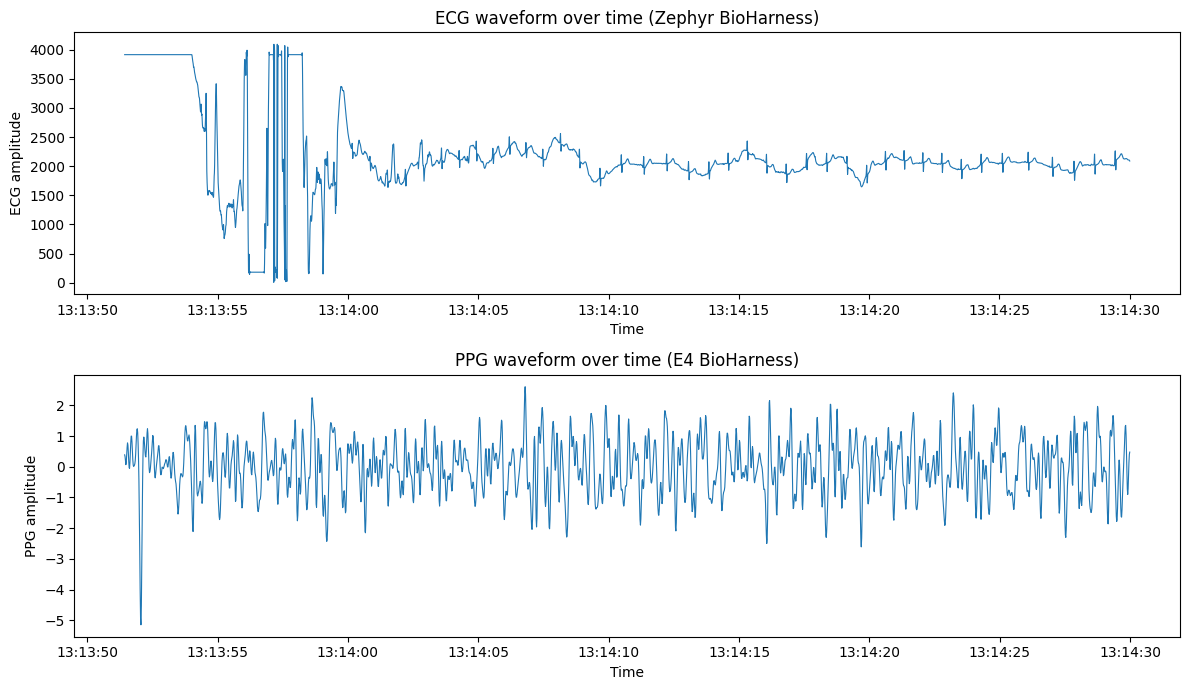

In [77]:
ecg_time = pd.to_datetime(data['zephyr']['ECG']['Time'])
ecg_time = pd.to_datetime(ecg_time)

ecg_raw = data['zephyr']['ECG']['EcgWaveform']

plt.figure(figsize=(12,7))
plt.subplot(2,1,1)
plt.plot(ecg_time, ecg_raw, linewidth=0.8)

plt.title("ECG waveform over time (Zephyr BioHarness)")
plt.xlabel("Time")
plt.ylabel("ECG amplitude")


ppg_time = pd.to_datetime(data['e4']['BVP']['Time'])
ppg_time = pd.to_datetime(ppg_time)
ppg_raw = data['e4']['BVP']['BVP']

plt.subplot(2,1,2)
plt.plot(ppg_time, ppg_raw, linewidth=0.8)
plt.title("PPG waveform over time (E4 BioHarness)")
plt.xlabel("Time")
plt.ylabel("PPG amplitude")
plt.tight_layout()
plt.show()


## **Find Bad segments using spectral analysis**

### Exploratory analysis of ECG signal quality using Welch PSD

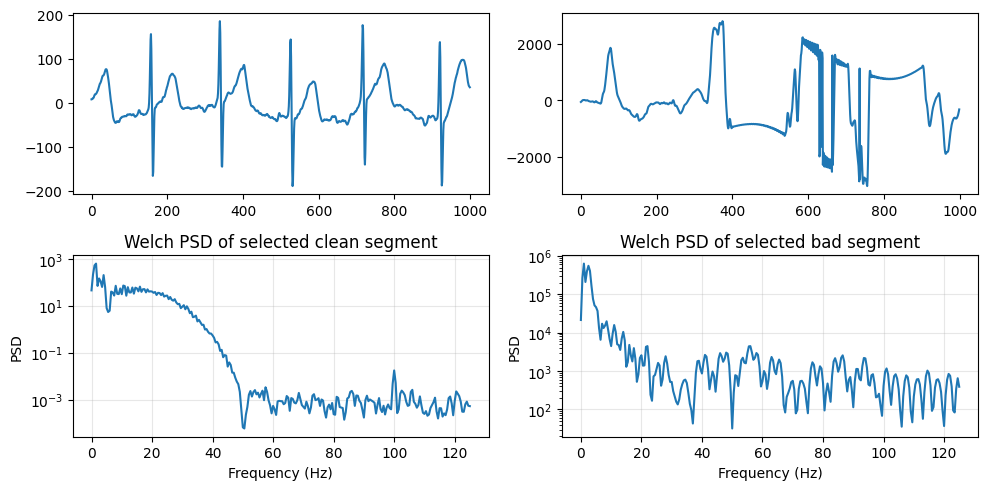

Clean segment bandpower after filter:
  Pin  (0.5-40 Hz): 521.9739043645147
  Pout (45-100 Hz) : 0.11782465608975848
  Pout/Pin ratio : 0.000225729016536192
  Pin/Pout ratio : 4430.090625232774
  Pin/(Pin+Pout) ratio: 99.97743219255536
bad segment bandpower after filter:
  Pin  (0.5-40 Hz): 30986.923312165578
  Pout (45-100 Hz) : 61035.785217762874
  Pout/Pin ratio : 1.9697271846863222
  Pin/Pout ratio : 0.5076845198535701
  Pin/(Pin+Pout) ratio: 33.673126782709


In [78]:
ecg_selected = ecg_raw[7500:8500]
ecg_bad = ecg_raw[800:1800]

fs = 250
in_band = (15, 40.0)
out_band = (45.0, 100.0)

res_selected = utils.compute_ecg_bandpowers(ecg_selected, fs, in_band, out_band, nperseg_sec=2, noverlap_ratio=0.8, apply_qc_filter=True)
res_bad = utils.compute_ecg_bandpowers(ecg_bad, fs, in_band, out_band, nperseg_sec=2, noverlap_ratio=0.8, apply_qc_filter=True)


# Plot PSD (log scale)
plt.figure(figsize=(10,7))

plt.subplot(3,2,1); plt.plot(res_selected['ecg_used'])
plt.subplot(3,2,2); plt.plot(res_bad['ecg_used'])

plt.subplot(3,2,3)
plt.semilogy(res_selected['f'], res_selected['Pxx']); plt.title(f"Welch PSD of selected clean segment"); plt.xlabel("Frequency (Hz)"); plt.ylabel("PSD"); plt.grid(True, alpha=0.3)

plt.subplot(3,2,4)
plt.semilogy(res_bad['f'], res_bad['Pxx']); plt.title(f"Welch PSD of selected bad segment"); plt.xlabel("Frequency (Hz)"); plt.ylabel("PSD"); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



print("Clean segment bandpower after filter:"); print("  Pin  (0.5-40 Hz):", res_selected['P_in']); print("  Pout (45-100 Hz) :", res_selected['P_out']); print("  Pout/Pin ratio :", res_selected['ratio']);
print("  Pin/Pout ratio :", res_selected['P_in'] / res_selected['P_out']);
pin_total_ratio = res_selected['P_in'] / (res_selected['P_in'] + res_selected['P_out']);
print(f"  Pin/(Pin+Pout) ratio: {pin_total_ratio*100}")

print('=='*30)
print("bad segment bandpower after filter:"); print("  Pin  (0.5-40 Hz):", res_bad['P_in']); print("  Pout (45-100 Hz) :", res_bad['P_out']); print("  Pout/Pin ratio :", res_bad['ratio'])
print("  Pin/Pout ratio :", res_bad['P_in'] / res_bad['P_out']);
pin_total_ratio = res_bad['P_in'] / (res_bad['P_in'] + res_bad['P_out']);
print(f"  Pin/(Pin+Pout) ratio: {pin_total_ratio*100}")

### Visual Validation of Bad ECG Segment Detection

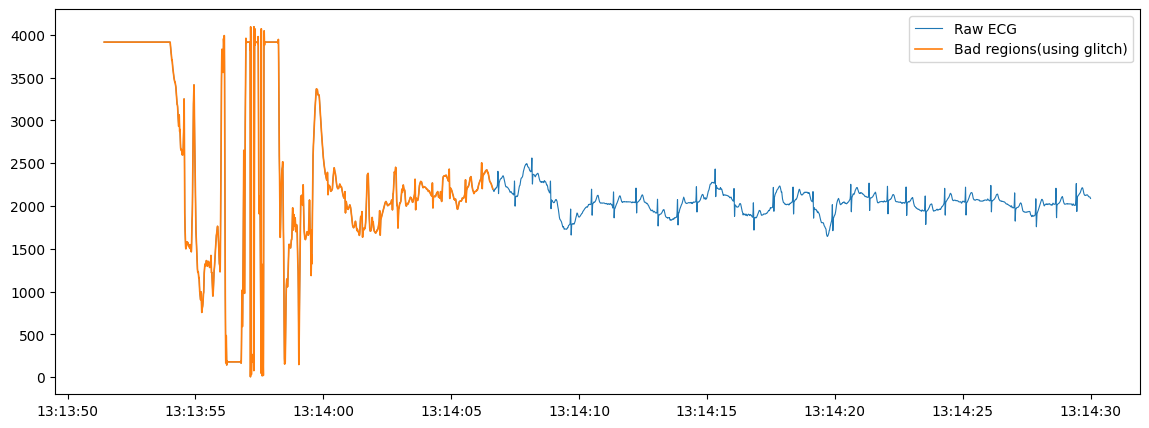

2562
1661
2039.0


dict_keys(['Pout', 'Pin', 'SNR', 'useful_ratio', 'bad_mask_psd', 'bad_mask_glitch', 'bad_segments_psd', 'bad_segments_glitch', 'bad_mask_psd_only', 'bad_mask_glitch_only', 'bad_mask_both', 'ecg_used'])

In [ ]:
bad_mask, bad_segments, info = utils.detect_bad_segments_hf_energy(
    ecg_raw,
    fs=250,
    out_band=(45.0, 100.0),
    win_sec = 6.0,
    thr_method = "robust"
)

ecg_bad = np.full_like(ecg_raw, np.nan, dtype=float)
# ecg_bad[bad_mask] = ecg_raw[bad_mask]
ecg_bad[info['bad_mask_psd_only']] = ecg_raw[info['bad_mask_psd_only']]
# ecg_bad[bad_mask] = ecg_raw[bad_mask]


plt.figure(figsize=(14,5))
plt.plot(ecg_time, ecg_raw, linewidth=0.8, label="Raw ECG")
ecg_bad[info['bad_mask_psd']] = ecg_raw[info['bad_mask_psd']]
# plt.plot(ecg_time, ecg_bad, linewidth=1.2, label="Bad regions(using PSD)")
ecg_bad[info['bad_mask_glitch']] = ecg_raw[info['bad_mask_glitch']]
plt.plot(ecg_time, ecg_bad, linewidth=1.2, label="Bad regions(using glitch)")
plt.legend();plt.show()

print(ecg_raw[4000:5000].max())
print(ecg_raw[4000:5000].min())
print(np.median(ecg_raw[4000:5000]))

info.keys()

## **detection of bad segments for multiple PKL files**

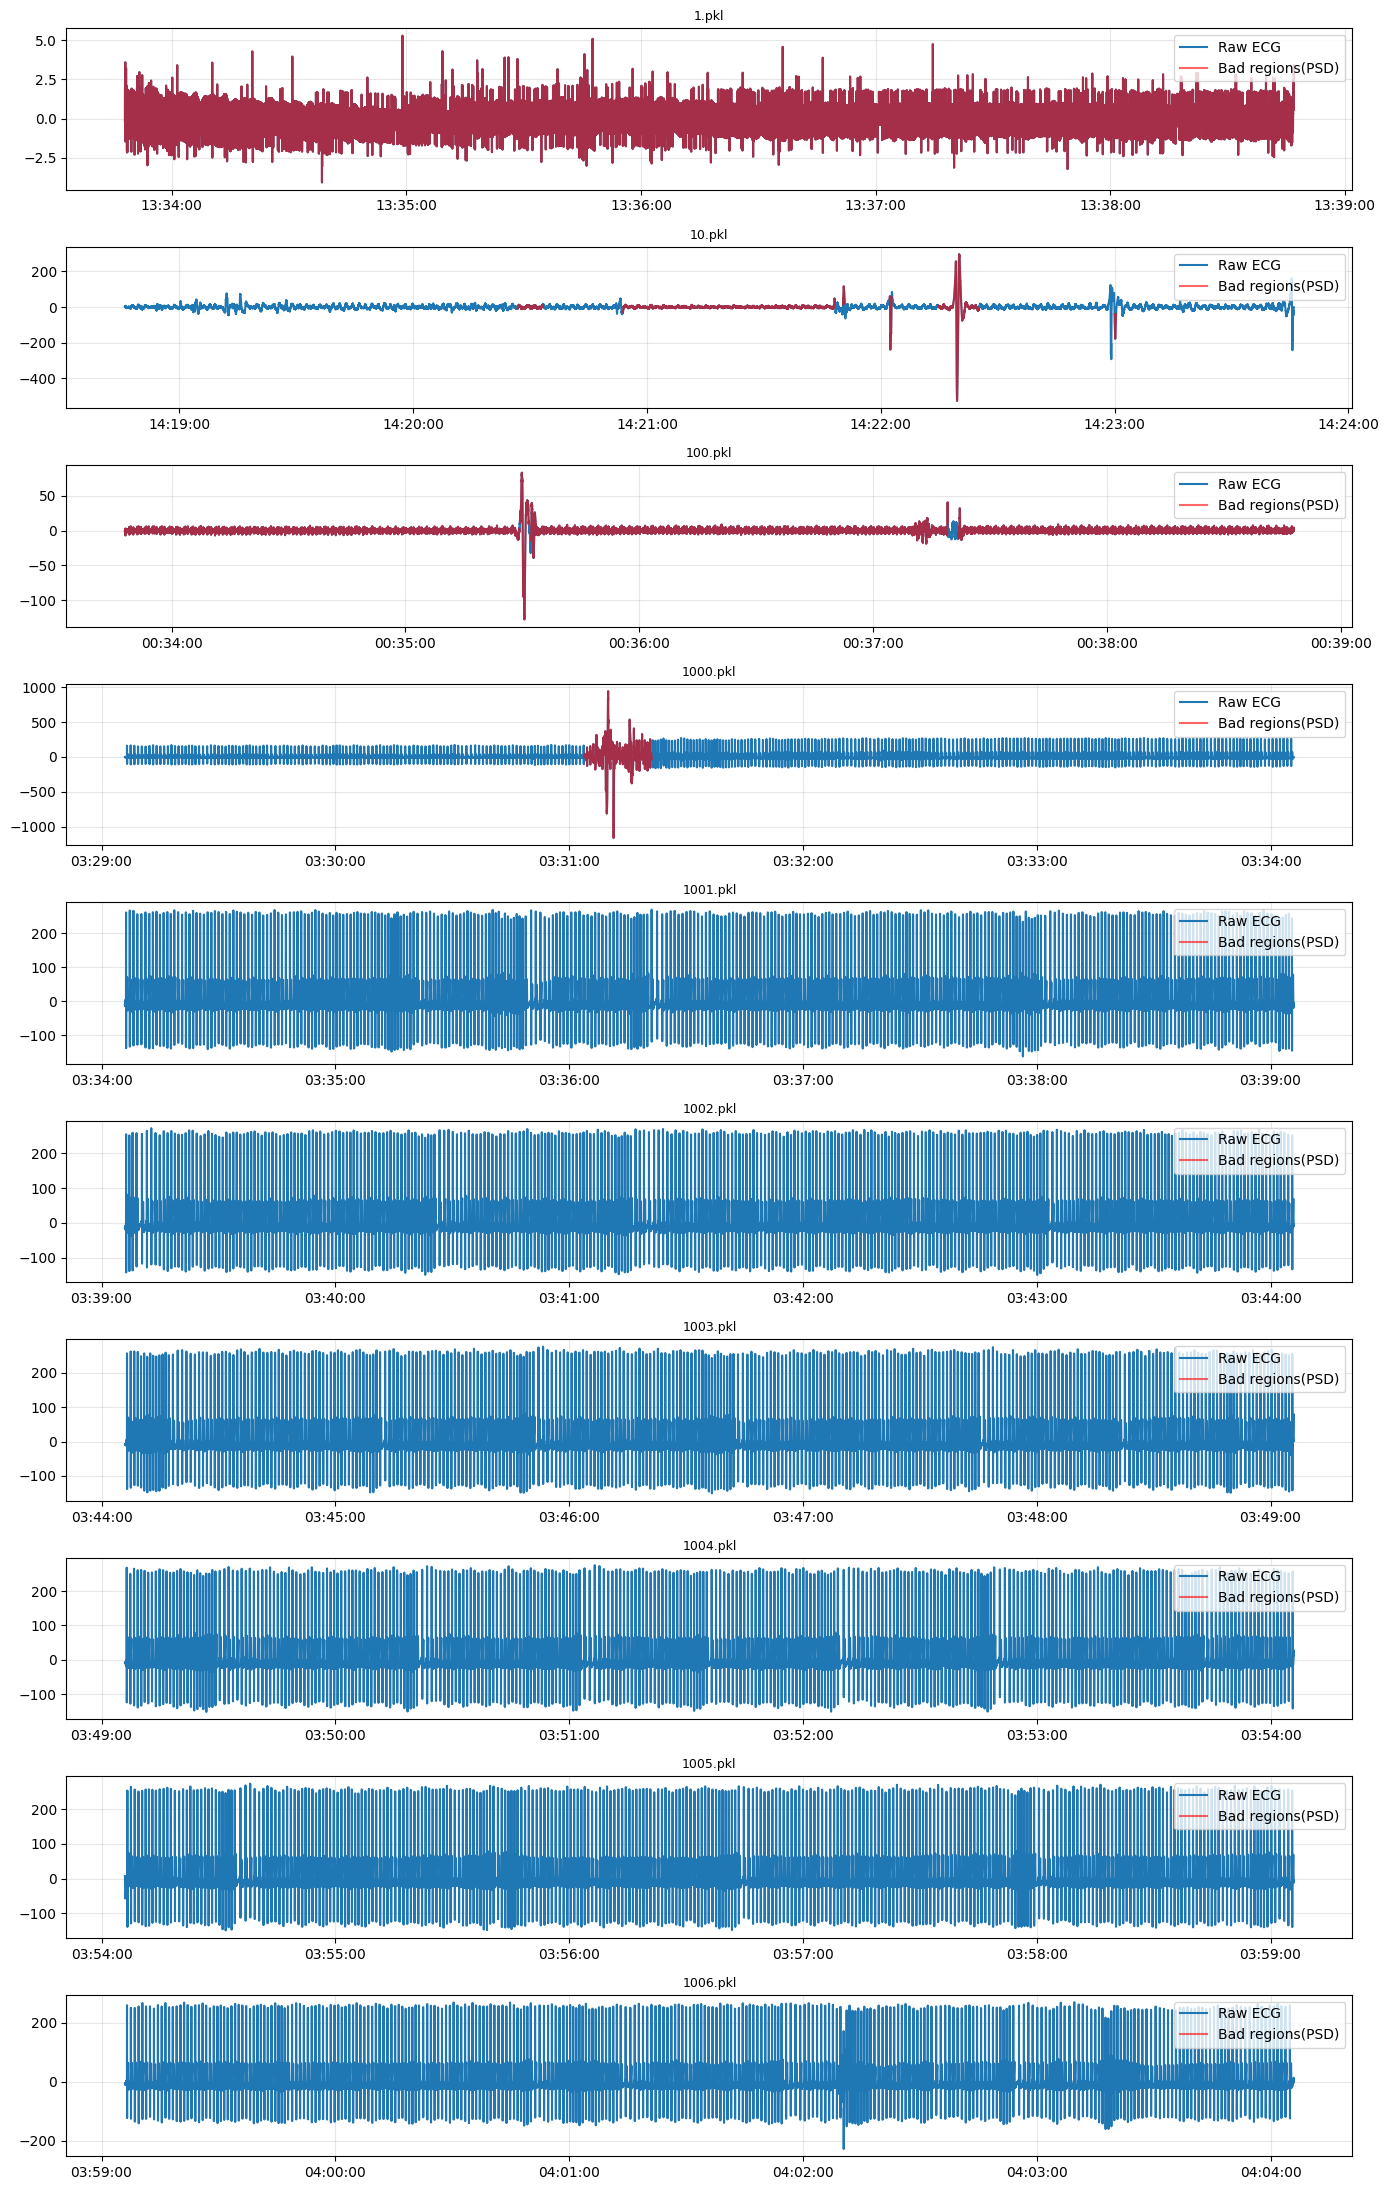

In [35]:
zip_path = "D:/KNTU/ARSHAD/Project/Datasets/c1s01_processed.zip"

fig, axes, _ = utils.plot_ecg_bad_segments_from_zip(
    zip_path,
    n_files=10,
    start_idx=1,
    fs=250,
    detector_kwargs=dict(
        thr_method="robust",
        k_amp=10,
        pad_glitch_sec=0.1,
        min_glitch_len_sec=0.2,
        glitch_win_sec=10.0,
    ),
    keep_sources=True,
)


# **Work with CGM Profiles of 1st subject**

### Extract CGM samples and available recording days

In [36]:
# ==============================
# CONFIGURATION
# ==============================
subject_folder_name = "0"       # <-- subject ID folder name inside ZIP

# ==============================
# READ ALL PKL FILES FROM ZIP
# ==============================
glucose_list = []
time_list = []

with zipfile.ZipFile(zip_path, 'r') as z:

    pkl_files = [f for f in z.namelist() if f.endswith(".pkl")]

    print(f"Total pkl files found: {len(pkl_files)}")

    for file in pkl_files:
        with z.open(file) as f:
            data = pickle.load(f)

            glucose_list.append(data['glucose'])
            time_list.append(data['Timestamp'])

# ==============================
# CREATE DATAFRAME
# ==============================
df = pd.DataFrame({
    'date_time': pd.to_datetime(time_list),
    'glucose': glucose_list
})

# Sort by date_time
df = df.sort_values('date_time')

# Extract date only
df['date'] = df['date_time'].dt.date
unique_dates = df['date'].unique()
df['time'] = df['date_time'].dt.time

print("Total CGM samples:", len(df))
print("Available days:", unique_dates)



Total pkl files found: 2704
Total CGM samples: 2704
Available days: [datetime.date(2022, 6, 8) datetime.date(2022, 6, 9)
 datetime.date(2022, 6, 10) datetime.date(2022, 6, 11)
 datetime.date(2022, 6, 12) datetime.date(2022, 6, 13)
 datetime.date(2022, 6, 14) datetime.date(2022, 6, 15)
 datetime.date(2022, 6, 16) datetime.date(2022, 6, 18)
 datetime.date(2022, 6, 23) datetime.date(2022, 6, 24)
 datetime.date(2022, 6, 25) datetime.date(2022, 6, 26)
 datetime.date(2022, 6, 28)]


### Plot daily CGM profiles

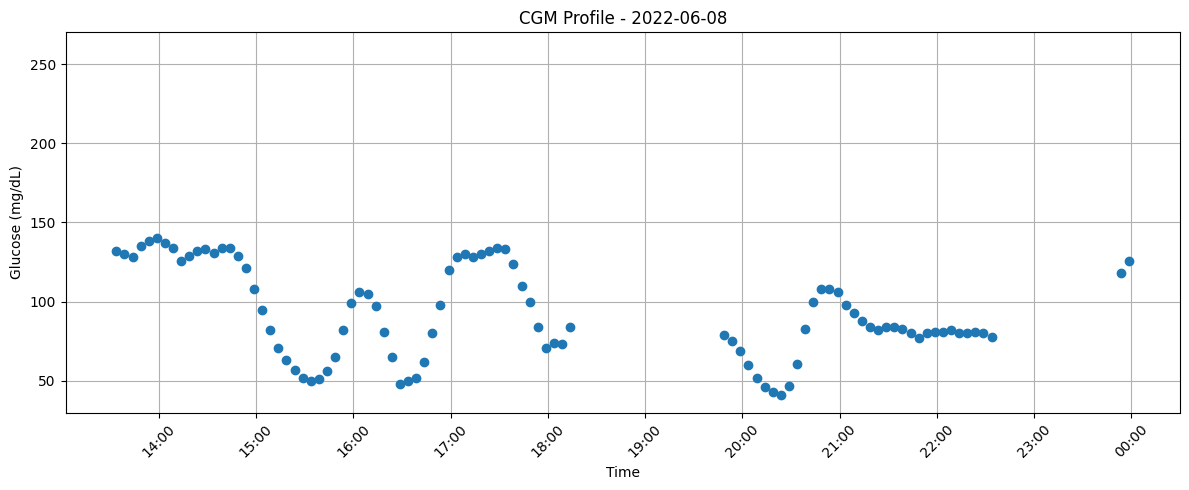

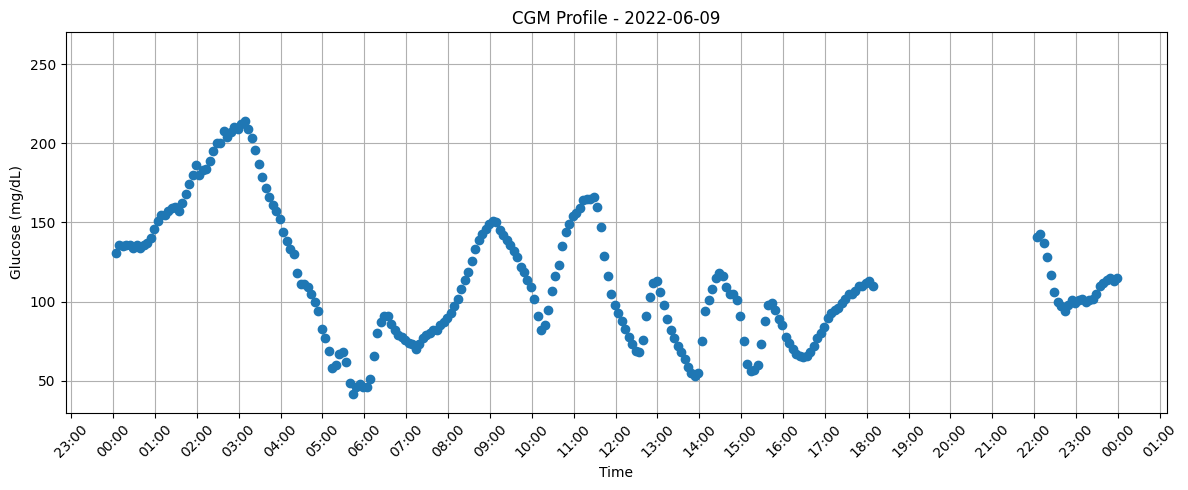

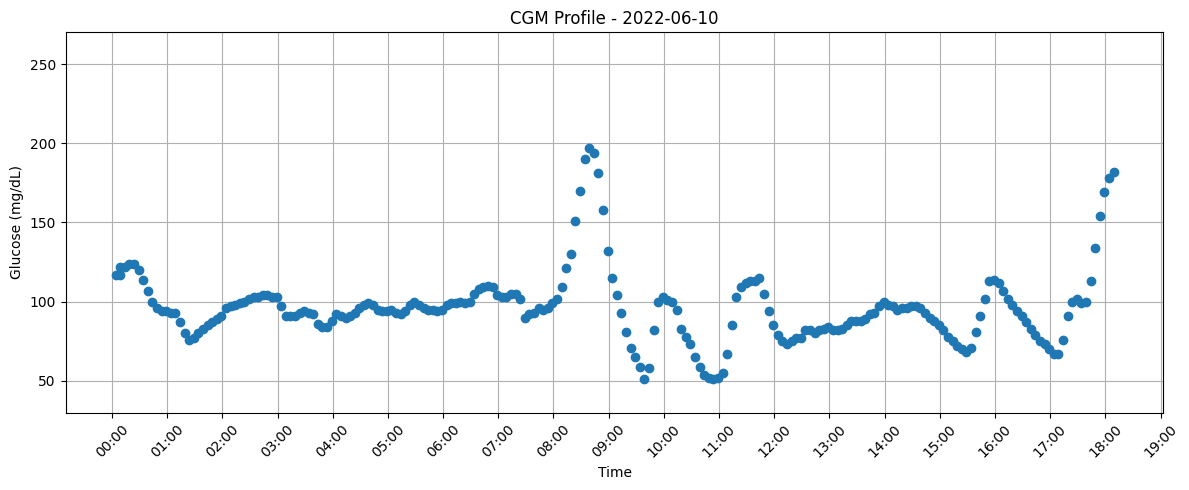

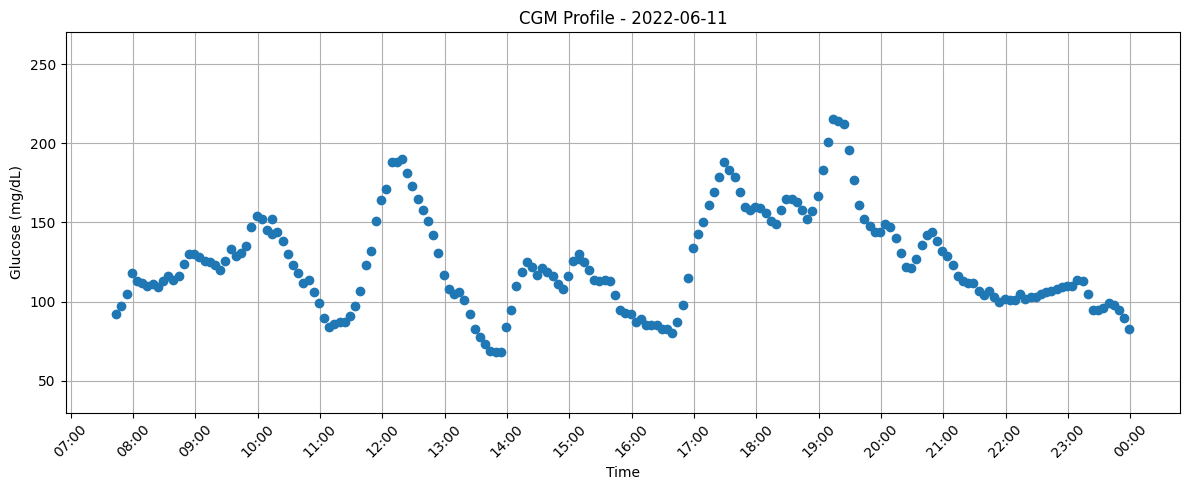

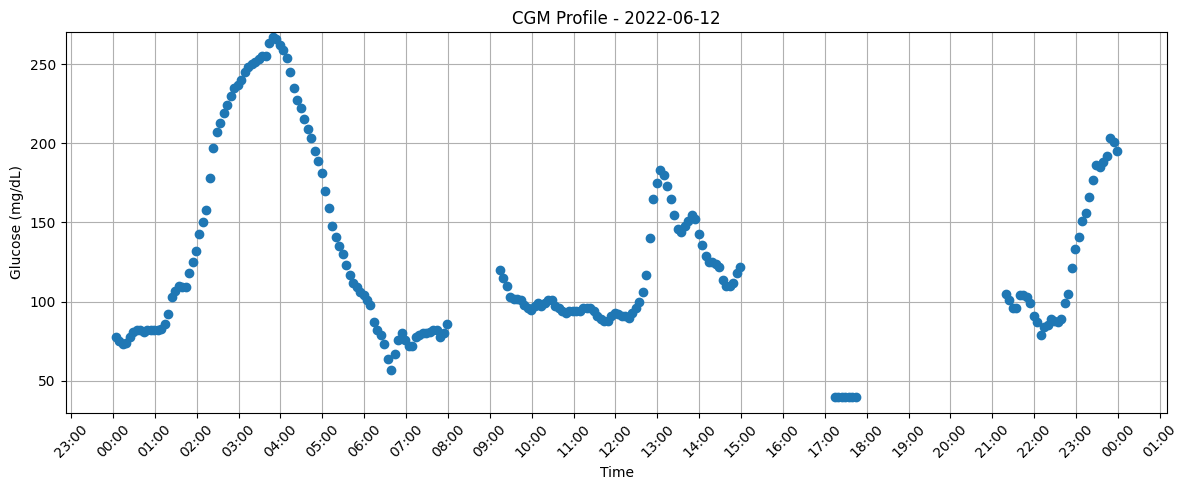

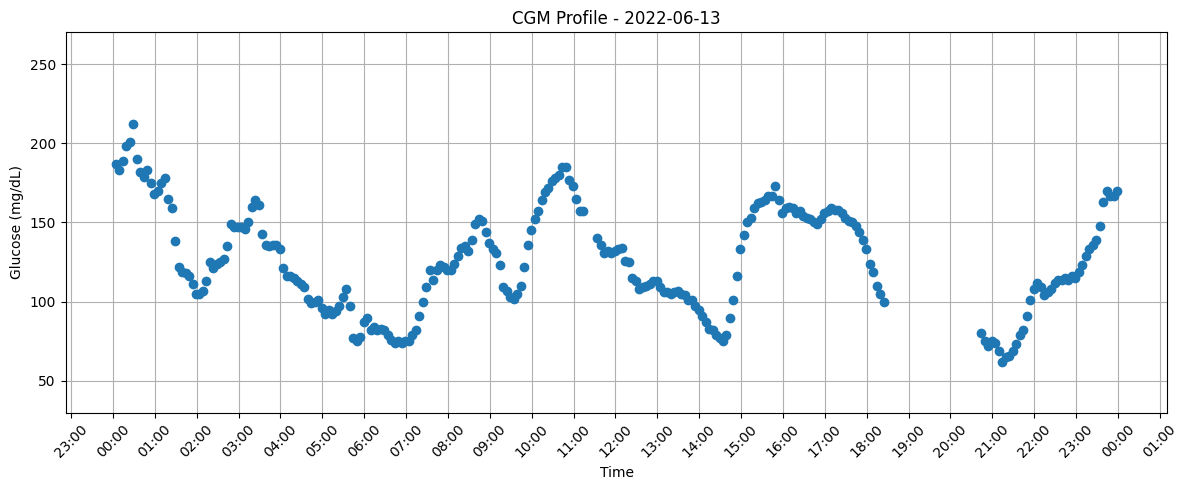

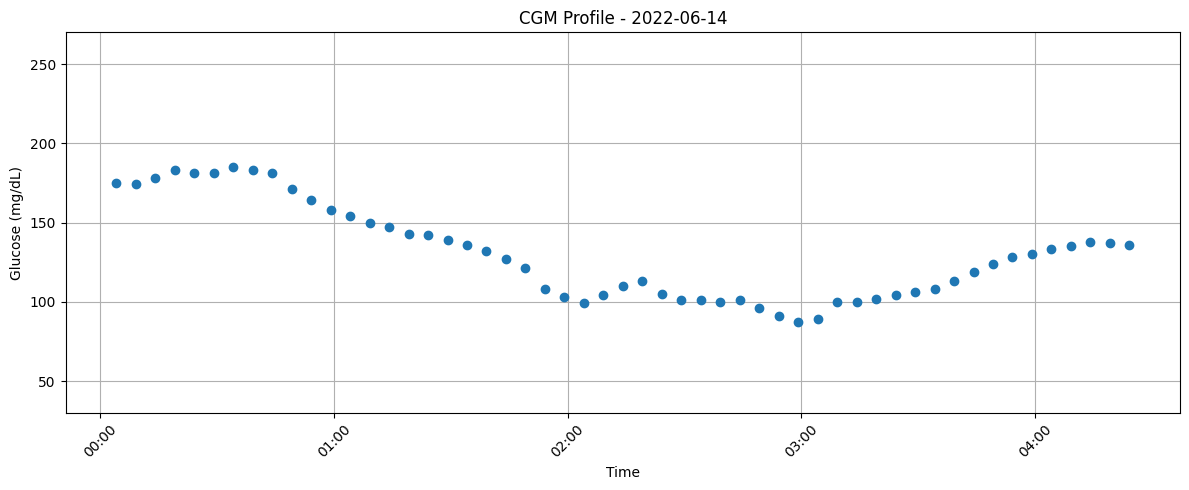

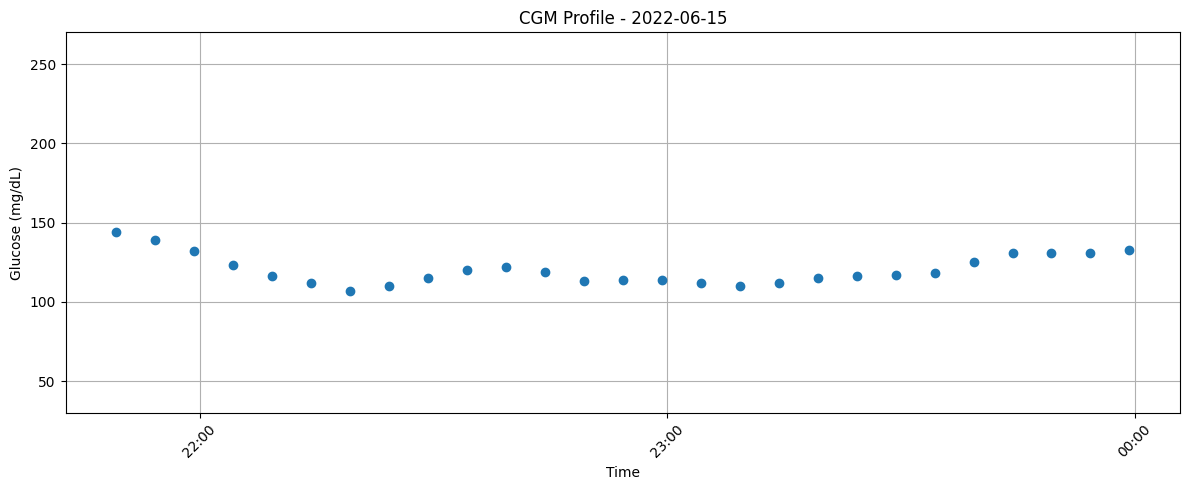

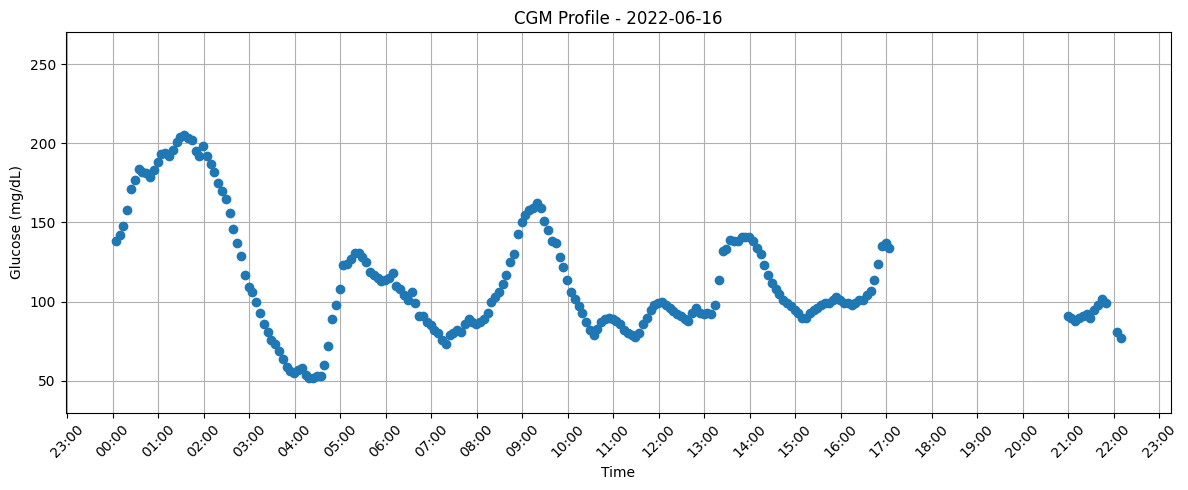

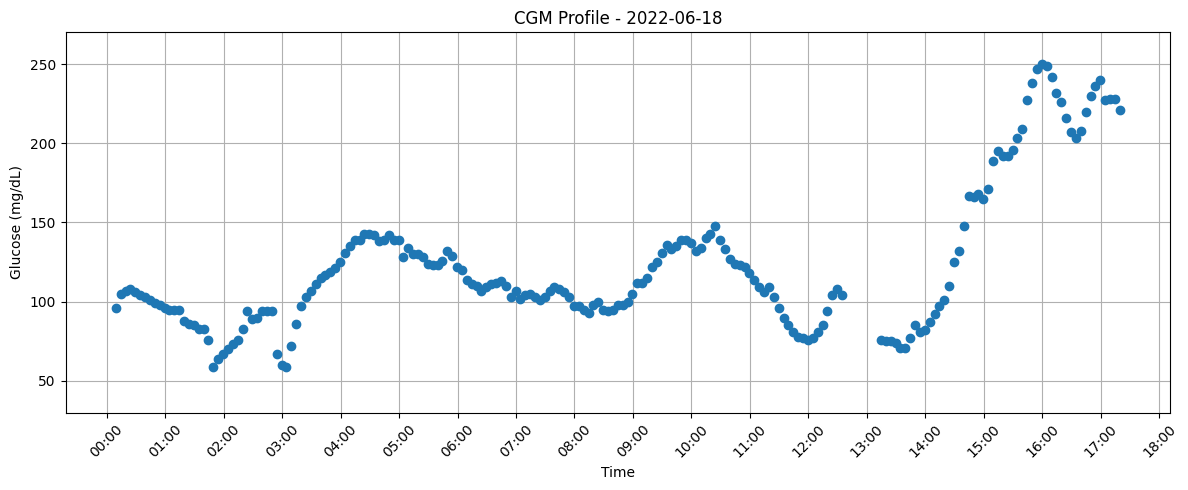

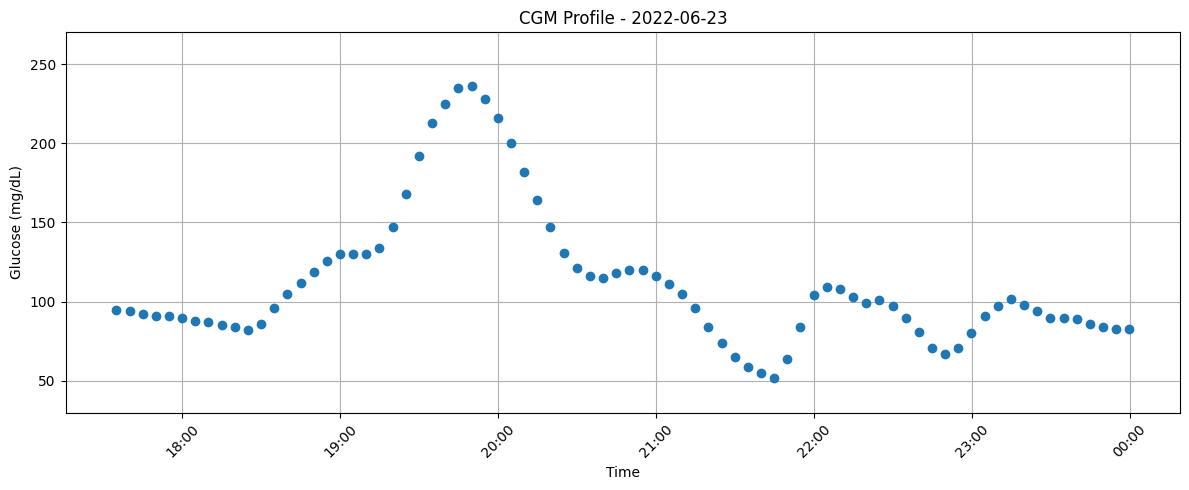

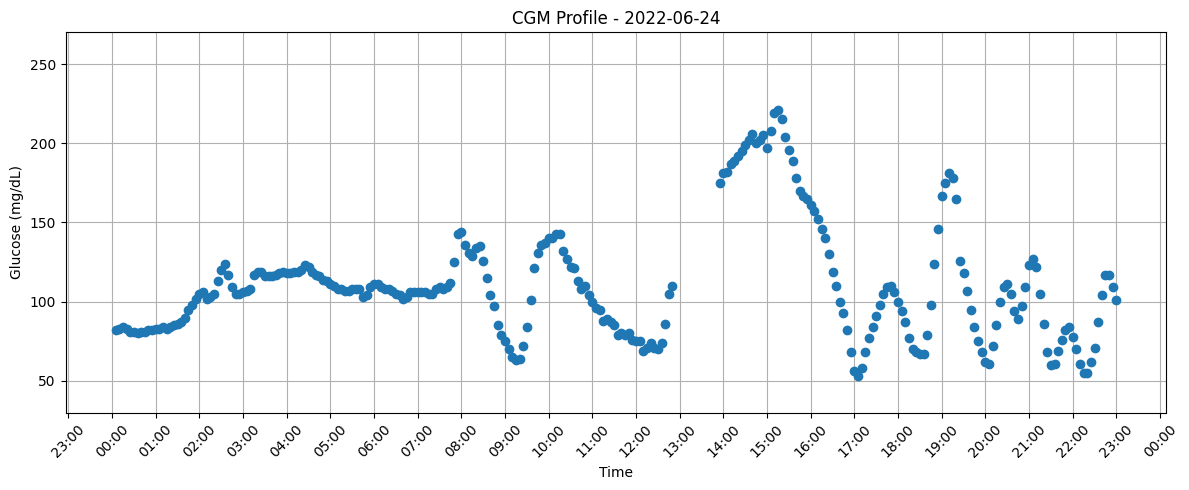

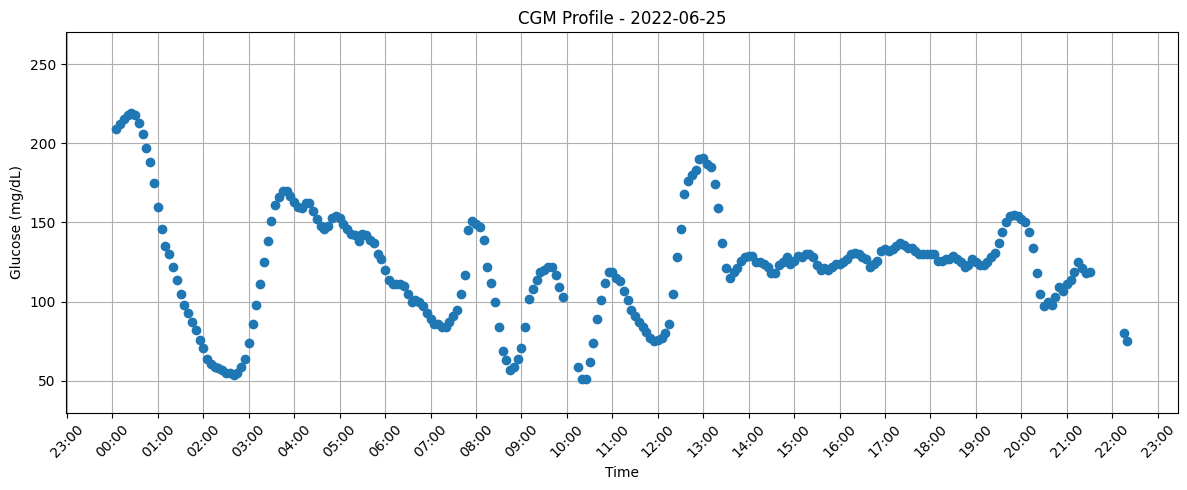

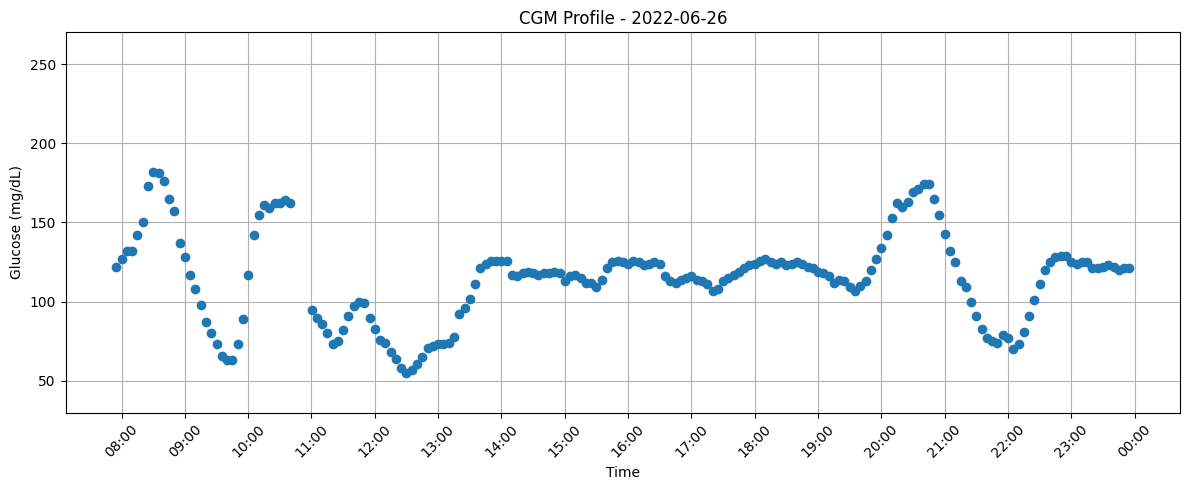

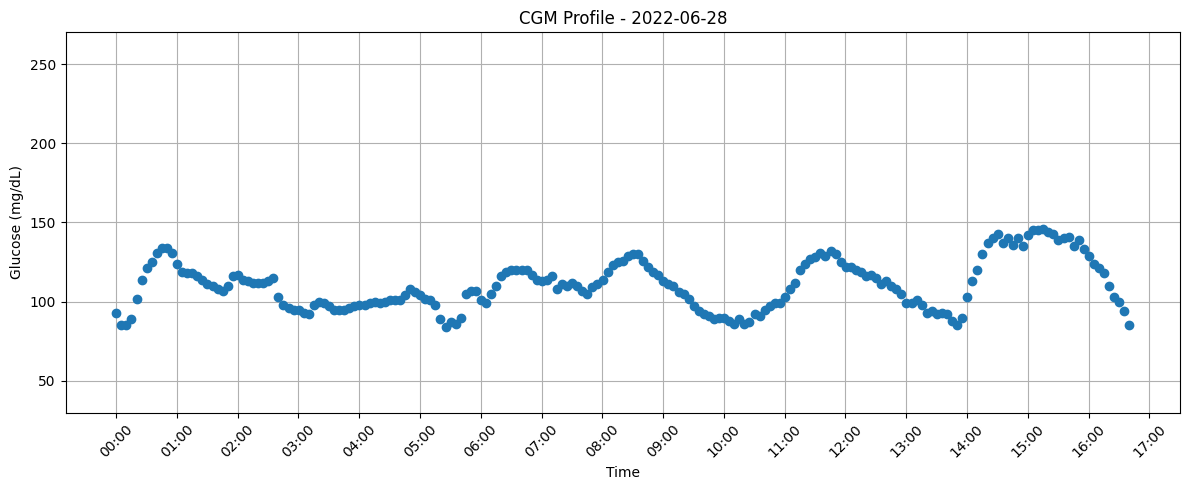

In [ ]:
for date in unique_dates:

    day_df = df[df['date'] == date]

    plt.figure(figsize=(12,5))
    plt.plot(day_df['date_time'], day_df['glucose'], marker='o', linestyle='')

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1)) # 

    plt.title(f"CGM Profile - {date}")
    plt.xlabel("Time")
    plt.ylim(30,270)
    plt.ylabel("Glucose (mg/dL)")

    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# **Build MATLAB Dataset from Valid ECG Cycles**
Steps:

- PKL recording from subject ZIP file
- ECG quality assessment
- Good segment extraction
- R-Peak detection
- 20-Cycle window construction
- Window validation
- Cycle extraction
- Cycle resampling (760 samples)
- CGM label assignment
- MATLAB dataset generation

In [67]:
abab = utils.process_zip_to_mat(
    zip_path,
    output_mat_path='subject1.mat',
    fs=250,
    target_len=760
)

Processing PKL files:   0%|          | 0/2704 [00:00<?, ?it/s]

[    5/2704] OK:,     1000.pkl,   (160, 762)
[    6/2704] OK:,     1001.pkl,   (300, 762)
[    7/2704] OK:,     1002.pkl,   (280, 762)
[    8/2704] OK:,     1003.pkl,   (260, 762)
[    9/2704] OK:,     1004.pkl,   (220, 762)
[   10/2704] OK:,     1005.pkl,   (260, 762)
[   11/2704] OK:,     1006.pkl,   (260, 762)
[   12/2704] OK:,     1007.pkl,   (280, 762)
[   13/2704] OK:,     1008.pkl,   (280, 762)
[   14/2704] OK:,     1009.pkl,   (300, 762)
[   16/2704] OK:,     1010.pkl,   (280, 762)
[   17/2704] OK:,     1011.pkl,   (300, 762)
[   18/2704] OK:,     1012.pkl,   (300, 762)
[   19/2704] OK:,     1013.pkl,   (180, 762)
[   20/2704] OK:,     1014.pkl,    (40, 762)
[   21/2704] OK:,     1015.pkl,   (260, 762)
[   22/2704] OK:,     1016.pkl,   (160, 762)
[   23/2704] OK:,     1017.pkl,    (20, 762)
[   25/2704] OK:,     1019.pkl,    (20, 762)
[   32/2704] OK:,     1025.pkl,    (20, 762)
[   33/2704] OK:,     1026.pkl,   (260, 762)
[   34/2704] OK:,     1027.pkl,   (260, 762)
[   35/270

c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[ 1464/2704] OK:,     2314.pkl,    (60, 762)
[ 1465/2704] OK:,     2315.pkl,   (180, 762)
[ 1466/2704] OK:,     2316.pkl,    (60, 762)
[ 1467/2704] OK:,     2317.pkl,   (220, 762)
[ 1468/2704] OK:,     2318.pkl,    (20, 762)
[ 1477/2704] OK:,     2326.pkl,   (200, 762)
[ 1478/2704] OK:,     2327.pkl,   (120, 762)
[ 1479/2704] OK:,     2328.pkl,   (400, 762)
[ 1480/2704] OK:,     2329.pkl,   (440, 762)
[ 1482/2704] OK:,     2330.pkl,   (420, 762)
[ 1483/2704] OK:,     2331.pkl,   (380, 762)
[ 1484/2704] OK:,     2332.pkl,   (380, 762)
[ 1485/2704] OK:,     2333.pkl,   (400, 762)
[ 1486/2704] OK:,     2334.pkl,   (440, 762)
[ 1487/2704] OK:,     2335.pkl,   (420, 762)
[ 1488/2704] OK:,     2336.pkl,   (400, 762)
[ 1489/2704] OK:,     2337.pkl,   (420, 762)
[ 1490/2704] OK:,     2338.pkl,   (400, 762)
[ 1491/2704] OK:,     2339.pkl,   (380, 762)
[ 1492/2704] OK:,      234.pkl,   (220, 762)
[ 1493/2704] OK:,     2340.pkl,   (400, 762)
[ 1494/2704] OK:,     2341.pkl,   (400, 762)
[ 1495/270